[*********************100%***********************]  5 of 5 completed

Data shape: (250, 25)
Data columns: MultiIndex([( 'Close',  'AAPL'),
            ( 'Close',  'AMZN'),
            ( 'Close', 'GOOGL'),
            ( 'Close',  'MSFT'),
            ( 'Close',  'NVDA'),
            (  'High',  'AAPL'),
            (  'High',  'AMZN'),
            (  'High', 'GOOGL'),
            (  'High',  'MSFT'),
            (  'High',  'NVDA'),
            (   'Low',  'AAPL'),
            (   'Low',  'AMZN'),
            (   'Low', 'GOOGL'),
            (   'Low',  'MSFT'),
            (   'Low',  'NVDA'),
            (  'Open',  'AAPL'),
            (  'Open',  'AMZN'),
            (  'Open', 'GOOGL'),
            (  'Open',  'MSFT'),
            (  'Open',  'NVDA'),
            ('Volume',  'AAPL'),
            ('Volume',  'AMZN'),
            ('Volume', 'GOOGL'),
            ('Volume',  'MSFT'),
            ('Volume',  'NVDA')],
           names=['Price', 'Ticker'])
Data columns levels: 2

Data downloaded successfully!
Period: 2023-01-01 to 2024-01-01
Number of tra

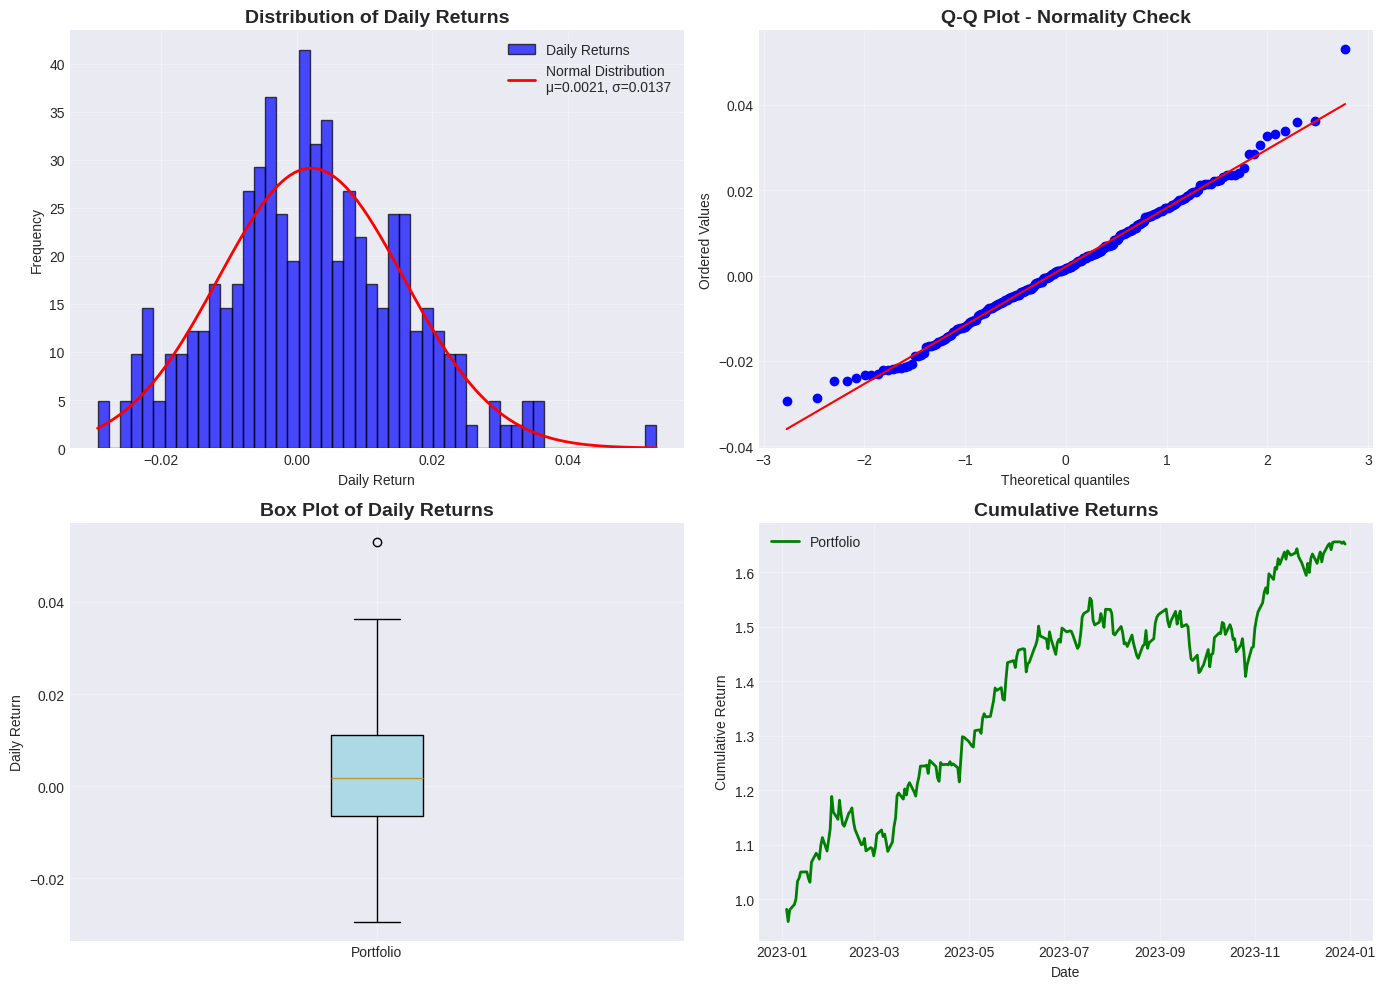

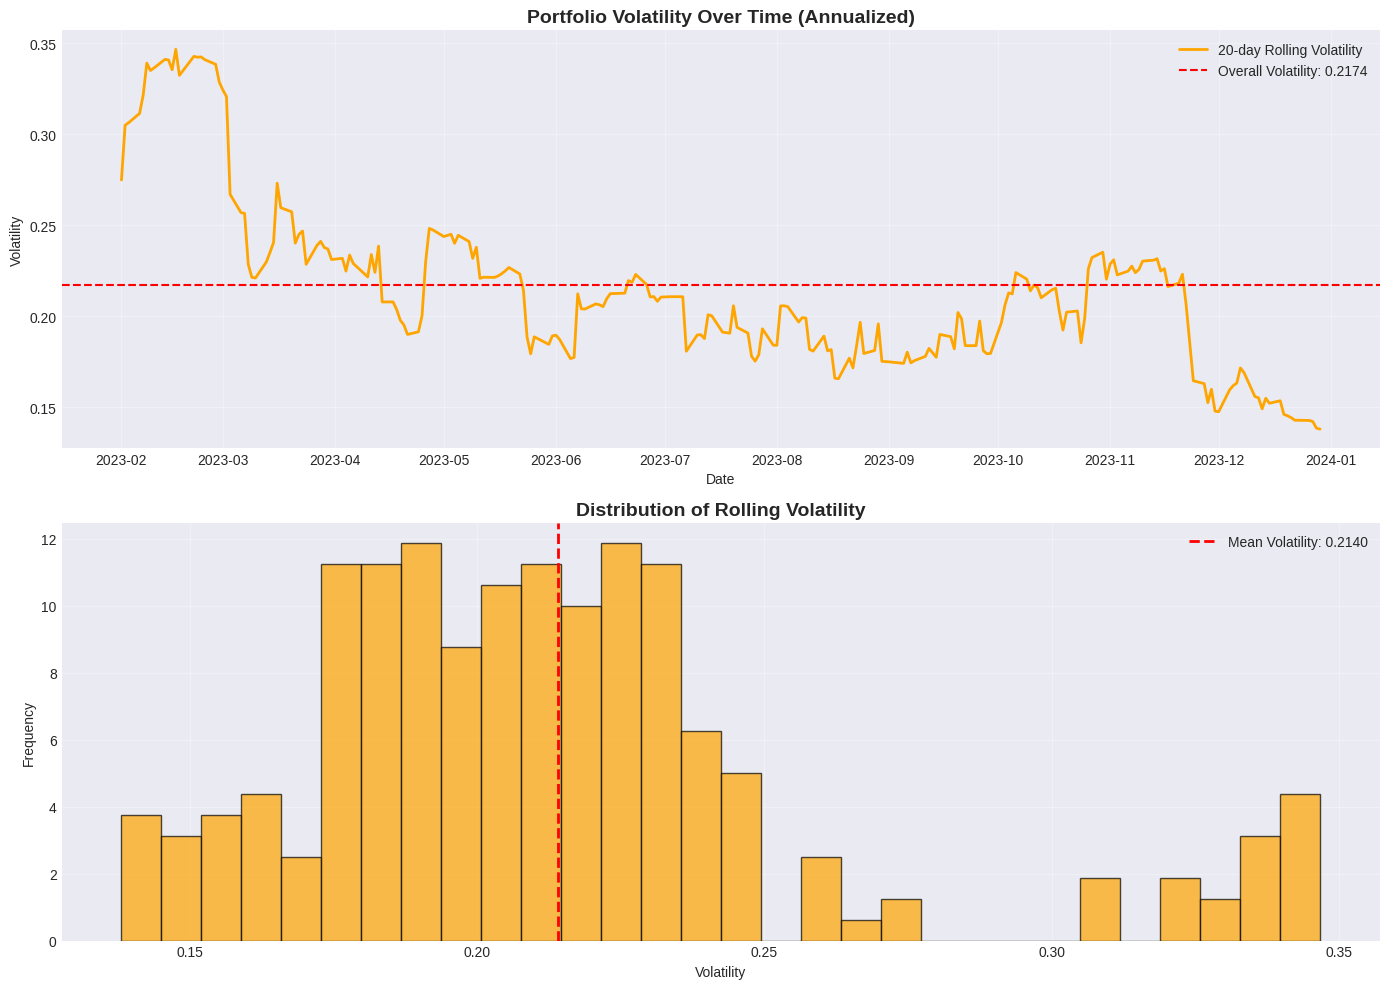


VALUE AT RISK (VaR) ANALYSIS

Portfolio Statistics:
Mean Daily Return: 0.002110
Std Daily Return: 0.013698
Annualized Return: 0.5318
Annualized Volatility: 0.2174
Sharpe Ratio (assuming 0% risk-free rate): 2.4454

------------------------------------------------------------
VALUE AT RISK (VaR) RESULTS
------------------------------------------------------------

Method               95% Confidence       99% Confidence      
------------------------------------------------------------
Historical VaR       -2.153%               -2.468%
Parametric VaR       -2.042%               -2.976%
Expected Shortfall   -2.392%               -2.758%

------------------------------------------------------------
VAR COMPARISON (in monetary terms for $100,000 portfolio)
------------------------------------------------------------

Method               95% Confidence       99% Confidence      
------------------------------------------------------------
Historical VaR       $-2,153.48             $-2,467

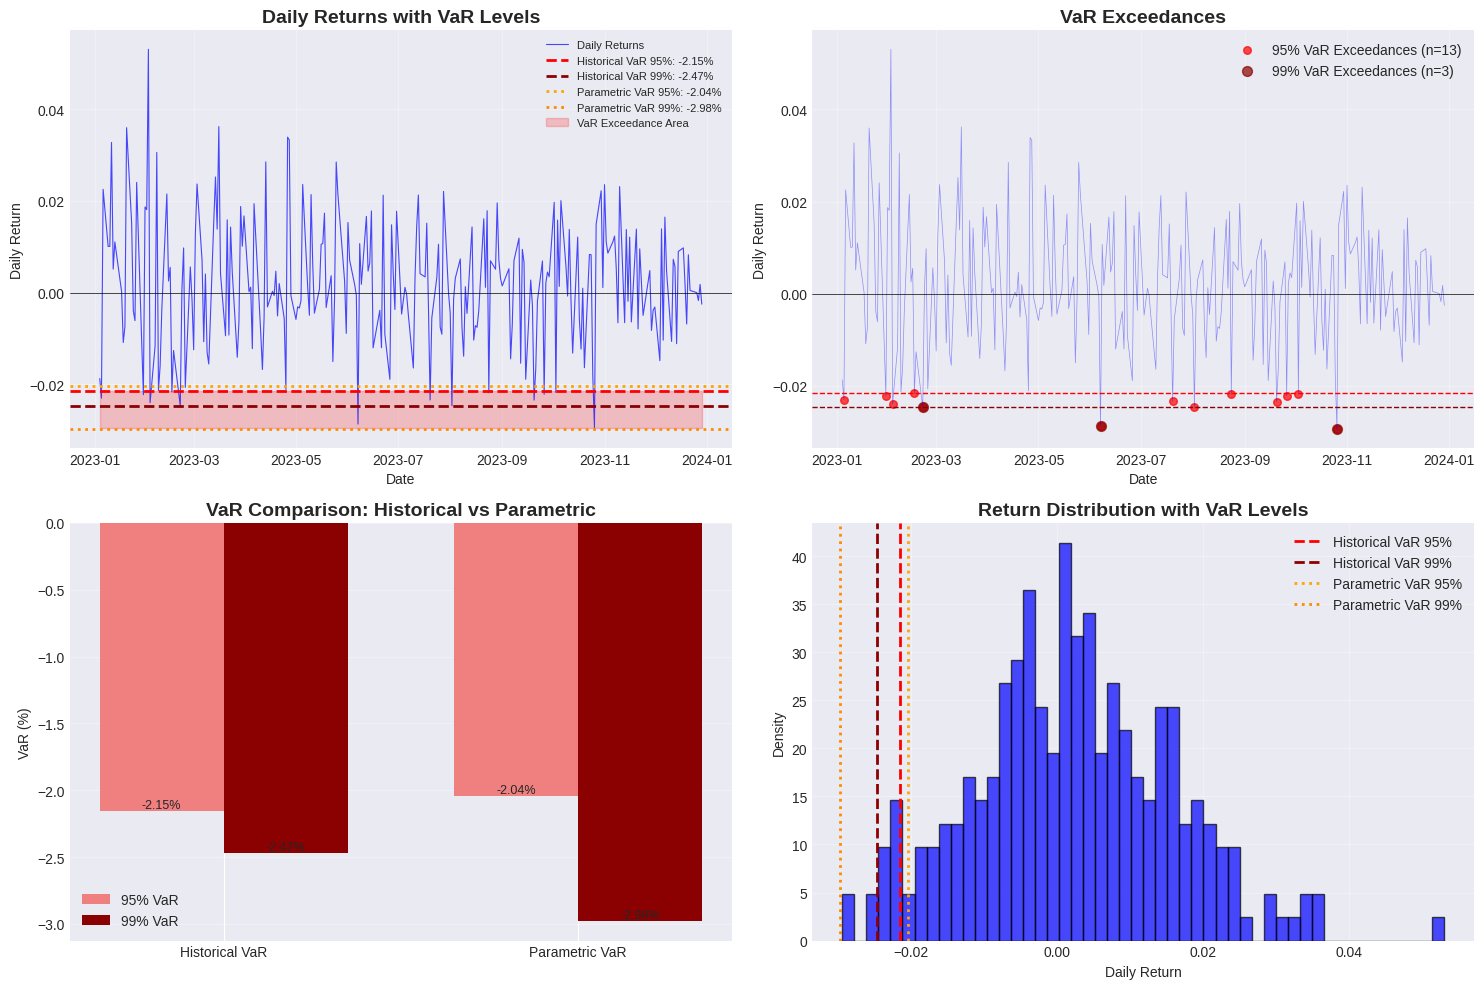


VAR BACKTESTING RESULTS

Total observations: 249

Confidence Level     Expected Exceedances      Actual Exceedances        Difference     
-------------------------------------------------------------------------------------
95%                   12.5                        13                       0.5
99%                    2.5                         3                       0.5

COMPARATIVE ANALYSIS: HISTORICAL VS PARAMETRIC VAR

At 95% confidence level:
  - Historical VaR: -2.153%
  - Parametric VaR: -2.042%
  - Difference: 5.17%

At 99% confidence level:
  - Historical VaR: -2.468%
  - Parametric VaR: -2.976%
  - Difference: 20.57%

INTERPRETATION AND DISCUSSION

1. Historical VaR Analysis:
   - This method is model-free and directly based on historical data
   - Captures actual market behavior and extreme events
   - Assumes that past returns are representative of future returns
   - Does not require any distributional assumptions

2. Parametric VaR Analysis:
   - Assumes returns

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Download historical price data for a portfolio of tech stocks
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
start_date = '2023-01-01'
end_date = '2024-01-01'

print("Downloading data from Yahoo Finance...")

# Download data - yfinance now returns data with 'Close' prices directly
data = yf.download(tickers, start=start_date, end=end_date)

# Check the structure of the data
print(f"Data shape: {data.shape}")
print(f"Data columns: {data.columns}")
print(f"Data columns levels: {data.columns.nlevels}")

# Extract adjusted close prices correctly
# If data has MultiIndex columns, extract 'Adj Close' or 'Close'
if data.columns.nlevels > 1:
    # For MultiIndex columns (ticker, price_type)
    try:
        # Try to get 'Adj Close' first
        adj_close = data['Adj Close']
    except KeyError:
        # If 'Adj Close' not available, use 'Close'
          adj_close = data['Close']
else:
    # For single level columns, it might be just prices
    adj_close = data

# If adj_close is a Series (single ticker) or DataFrame
if isinstance(adj_close, pd.Series):
    # Single ticker case
    portfolio_prices = adj_close
else:
    # Multiple tickers case - calculate portfolio returns
    # Ensure we have the correct tickers
    available_tickers = [col for col in adj_close.columns if col in tickers]
    if not available_tickers:
        available_tickers = adj_close.columns.tolist()

    # Use available tickers
    weights = np.array([1/len(available_tickers)] * len(available_tickers))
    portfolio_prices = (adj_close[available_tickers] * weights).sum(axis=1)

# Calculate returns
daily_returns = portfolio_prices.pct_change().dropna()

# Calculate individual stock returns for comparison
if isinstance(adj_close, pd.DataFrame):
    stock_returns = adj_close[available_tickers].pct_change().dropna()
else:
    stock_returns = None

print(f"\nData downloaded successfully!")
print(f"Period: {start_date} to {end_date}")
print(f"Number of trading days: {len(daily_returns)}")
if isinstance(adj_close, pd.DataFrame):
    print(f"Portfolio: {', '.join(available_tickers)}")
else:
    print(f"Ticker: {tickers[0]}")

# 1. VISUALIZE DAILY RETURNS DISTRIBUTION
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of returns
ax1 = axes[0, 0]
n, bins, patches = ax1.hist(daily_returns, bins=50, density=True, alpha=0.7,
                            color='blue', edgecolor='black', label='Daily Returns')

# Overlay normal distribution
mu = daily_returns.mean()
sigma = daily_returns.std()
x = np.linspace(daily_returns.min(), daily_returns.max(), 100)
y = norm.pdf(x, mu, sigma)
ax1.plot(x, y, 'r-', linewidth=2, label=f'Normal Distribution\nμ={mu:.4f}, σ={sigma:.4f}')
ax1.set_title('Distribution of Daily Returns', fontsize=14, fontweight='bold')
ax1.set_xlabel('Daily Return')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# QQ plot for normality check
ax2 = axes[0, 1]
stats.probplot(daily_returns, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot - Normality Check', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Box plot of returns
ax3 = axes[1, 0]
ax3.boxplot(daily_returns, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))

ax3.set_title('Box Plot of Daily Returns', fontsize=14, fontweight='bold')
ax3.set_ylabel('Daily Return')
ax3.set_xticklabels(['Portfolio'])
ax3.grid(True, alpha=0.3)

# Cumulative returns
ax4 = axes[1, 1]
cumulative_returns = (1 + daily_returns).cumprod()
ax4.plot(cumulative_returns.index, cumulative_returns,
         color='green', linewidth=2, label='Portfolio')
ax4.set_title('Cumulative Returns', fontsize=14, fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Cumulative Return')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.savefig('returns_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. COMPUTE DAILY VOLATILITY AND PLOT OVER TIME
rolling_window = 20  # 20-day rolling volatility
rolling_volatility = daily_returns.rolling(window=rolling_window).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Volatility over time
ax1 = axes[0]
ax1.plot(rolling_volatility.index, rolling_volatility,
         color='orange', linewidth=2, label=f'{rolling_window}-day Rolling Volatility')
ax1.axhline(y=daily_returns.std() * np.sqrt(252), color='red',
            linestyle='--', linewidth=1.5, label=f'Overall Volatility: {daily_returns.std()*np.sqrt(252):.4f}')
ax1.set_title('Portfolio Volatility Over Time (Annualized)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Volatility')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volatility distribution
ax2 = axes[1]
ax2.hist(rolling_volatility.dropna(), bins=30, alpha=0.7,
         color='orange', edgecolor='black', density=True)
ax2.axvline(x=rolling_volatility.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean Volatility: {rolling_volatility.mean():.4f}')
ax2.set_title('Distribution of Rolling Volatility', fontsize=14, fontweight='bold')
ax2.set_xlabel('Volatility')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('volatility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. CALCULATE VAR USING DIFFERENT METHODS

# Historical VaR
historical_var_95 = np.percentile(daily_returns, 5)
historical_var_99 = np.percentile(daily_returns, 1)

# Parametric VaR (assuming normal distribution)
z_score_95 = norm.ppf(0.05)
z_score_99 = norm.ppf(0.01)
parametric_var_95 = mu + z_score_95 * sigma
parametric_var_99 = mu + z_score_99 * sigma

# Expected Shortfall (CVaR) for completeness
expected_shortfall_95 = daily_returns[daily_returns <= historical_var_95].mean()
expected_shortfall_99 = daily_returns[daily_returns <= historical_var_99].mean()

print("\n" + "="*60)
print("VALUE AT RISK (VaR) ANALYSIS")
print("="*60)
print(f"\nPortfolio Statistics:")
print(f"Mean Daily Return: {mu:.6f}")
print(f"Std Daily Return: {sigma:.6f}")
print(f"Annualized Return: {mu*252:.4f}")
print(f"Annualized Volatility: {sigma*np.sqrt(252):.4f}")
print(f"Sharpe Ratio (assuming 0% risk-free rate): {mu*252/(sigma*np.sqrt(252)):.4f}")

print("\n" + "-"*60)
print("VALUE AT RISK (VaR) RESULTS")
print("-"*60)

print(f"\n{'Method':<20} {'95% Confidence':<20} {'99% Confidence':<20}")
print("-"*60)
print(f"{'Historical VaR':<20} {historical_var_95*100:>6.3f}%{'':<14} {historical_var_99*100:>6.3f}%")
print(f"{'Parametric VaR':<20} {parametric_var_95*100:>6.3f}%{'':<14} {parametric_var_99*100:>6.3f}%")
print(f"{'Expected Shortfall':<20} {expected_shortfall_95*100:>6.3f}%{'':<14} {expected_shortfall_99*100:>6.3f}%")

print("\n" + "-"*60)
print("VAR COMPARISON (in monetary terms for $100,000 portfolio)")
print("-"*60)
portfolio_value = 100000
print(f"\n{'Method':<20} {'95% Confidence':<20} {'99% Confidence':<20}")
print("-"*60)
print(f"{'Historical VaR':<20} ${historical_var_95*portfolio_value:>8,.2f}{'':<12} ${historical_var_99*portfolio_value:>8,.2f}")
print(f"{'Parametric VaR':<20} ${parametric_var_95*portfolio_value:>8,.2f}{'':<12} ${parametric_var_99*portfolio_value:>8,.2f}")
print(f"{'Expected Shortfall':<20} ${expected_shortfall_95*portfolio_value:>8,.2f}{'':<12} ${expected_shortfall_99*portfolio_value:>8,.2f}")

# 4. PLOT RETURNS WITH VAR LEVELS
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Daily returns with VaR levels
ax1 = axes[0, 0]
ax1.plot(daily_returns.index, daily_returns, color='blue', alpha=0.7, linewidth=0.8, label='Daily Returns')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.axhline(y=historical_var_95, color='red', linestyle='--', linewidth=2,
            label=f'Historical VaR 95%: {historical_var_95*100:.2f}%')
ax1.axhline(y=historical_var_99, color='darkred', linestyle='--', linewidth=2,
            label=f'Historical VaR 99%: {historical_var_99*100:.2f}%')
ax1.axhline(y=parametric_var_95, color='orange', linestyle=':', linewidth=2,
            label=f'Parametric VaR 95%: {parametric_var_95*100:.2f}%')
ax1.axhline(y=parametric_var_99, color='darkorange', linestyle=':', linewidth=2,
            label=f'Parametric VaR 99%: {parametric_var_99*100:.2f}%')
ax1.fill_between(daily_returns.index, daily_returns.min(), historical_var_95,
                  alpha=0.2, color='red', label='VaR Exceedance Area')
ax1.set_title('Daily Returns with VaR Levels', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Return')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Exceedances
ax2 = axes[0, 1]
exceedances_95 = daily_returns[daily_returns < historical_var_95]
exceedances_99 = daily_returns[daily_returns < historical_var_99]
ax2.scatter(exceedances_95.index, exceedances_95, color='red', s=30,
            alpha=0.7, label=f'95% VaR Exceedances (n={len(exceedances_95)})')
ax2.scatter(exceedances_99.index, exceedances_99, color='darkred', s=50,
            alpha=0.7, label=f'99% VaR Exceedances (n={len(exceedances_99)})')
ax2.plot(daily_returns.index, daily_returns, color='blue', alpha=0.4, linewidth=0.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.axhline(y=historical_var_95, color='red', linestyle='--', linewidth=1)
ax2.axhline(y=historical_var_99, color='darkred', linestyle='--', linewidth=1)
ax2.set_title('VaR Exceedances', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Daily Return')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bar chart comparison
ax3 = axes[1, 0]
methods = ['Historical VaR', 'Parametric VaR']
x = np.arange(len(methods))
width = 0.35
bars1 = ax3.bar(x - width/2, [historical_var_95*100, parametric_var_95*100],
                width, label='95% VaR', color=['lightcoral', 'lightcoral'])
bars2 = ax3.bar(x + width/2, [historical_var_99*100, parametric_var_99*100],
                width, label='99% VaR', color=['darkred', 'darkred'])
ax3.set_ylabel('VaR (%)')
ax3.set_title('VaR Comparison: Historical vs Parametric', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(methods)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# Return distribution with VaR markers
ax4 = axes[1, 1]
n, bins, patches = ax4.hist(daily_returns, bins=50, density=True,
                            alpha=0.7, color='blue', edgecolor='black')
ax4.axvline(x=historical_var_95, color='red', linestyle='--', linewidth=2,
            label=f'Historical VaR 95%')
ax4.axvline(x=historical_var_99, color='darkred', linestyle='--', linewidth=2,
            label=f'Historical VaR 99%')
ax4.axvline(x=parametric_var_95, color='orange', linestyle=':', linewidth=2,
            label=f'Parametric VaR 95%')
ax4.axvline(x=parametric_var_99, color='darkorange', linestyle=':', linewidth=2,
            label=f'Parametric VaR 99%')
ax4.set_title('Return Distribution with VaR Levels', fontsize=14, fontweight='bold')
ax4.set_xlabel('Daily Return')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('var_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. BACKTESTING - COMPARE EXPECTED VS ACTUAL EXCEEDANCES
expected_exceedances_95 = len(daily_returns) * 0.05
expected_exceedances_99 = len(daily_returns) * 0.01
actual_exceedances_95 = len(daily_returns[daily_returns < historical_var_95])
actual_exceedances_99 = len(daily_returns[daily_returns < historical_var_99])

print("\n" + "="*60)
print("VAR BACKTESTING RESULTS")
print("="*60)
print(f"\nTotal observations: {len(daily_returns)}")
print(f"\n{'Confidence Level':<20} {'Expected Exceedances':<25} {'Actual Exceedances':<25} {'Difference':<15}")
print("-"*85)
print(f"{'95%':<20} {expected_exceedances_95:>5.1f}{'':<20} {actual_exceedances_95:>5}{'':<20} {actual_exceedances_95 - expected_exceedances_95:>5.1f}")
print(f"{'99%':<20} {expected_exceedances_99:>5.1f}{'':<20} {actual_exceedances_99:>5}{'':<20} {actual_exceedances_99 - expected_exceedances_99:>5.1f}")

# 6. COMPARATIVE ANALYSIS
print("\n" + "="*60)
print("COMPARATIVE ANALYSIS: HISTORICAL VS PARAMETRIC VAR")
print("="*60)

diff_95 = abs(historical_var_95 - parametric_var_95) / abs(historical_var_95) * 100
diff_99 = abs(historical_var_99 - parametric_var_99) / abs(historical_var_99) * 100

print(f"\nAt 95% confidence level:")
print(f"  - Historical VaR: {historical_var_95*100:.3f}%")
print(f"  - Parametric VaR: {parametric_var_95*100:.3f}%")
print(f"  - Difference: {diff_95:.2f}%")

print(f"\nAt 99% confidence level:")
print(f"  - Historical VaR: {historical_var_99*100:.3f}%")
print(f"  - Parametric VaR: {parametric_var_99*100:.3f}%")
print(f"  - Difference: {diff_99:.2f}%")

# 7. INTERPRETATION AND DISCUSSION
print("\n" + "="*60)
print("INTERPRETATION AND DISCUSSION")
print("="*60)

print("\n1. Historical VaR Analysis:")
print("   - This method is model-free and directly based on historical data")
print("   - Captures actual market behavior and extreme events")
print("   - Assumes that past returns are representative of future returns")
print("   - Does not require any distributional assumptions")

print("\n2. Parametric VaR Analysis:")
print("   - Assumes returns follow a normal distribution")
print("   - More computationally efficient")
print("   - May underestimate risk during market stress periods")
print("   - Fails to capture fat tails and skewness in returns")

print("\n3. Key Observations:")
print(f"   - Historical VaR is {diff_95:.1f}% different from Parametric VaR at 95% confidence")
print(f"   - Historical VaR is {diff_99:.1f}% different from Parametric VaR at 99% confidence")
print("   - The portfolio shows evidence of fat tails if kurtosis > 3")

print("\n4. Recommendations:")
print("   - Use multiple VaR methods for a comprehensive risk assessment")
print("   - Historical VaR is preferred during normal market conditions")
print("   - Parametric VaR can be used for quick approximations")
print("   - Consider Expected Shortfall (CVaR) for tail risk management")
print("   - Regular backtesting is essential to validate VaR models")

print("\n5. Limitations:")
print("   - Historical VaR assumes past patterns will repeat")
print("   - Parametric VaR may fail during market crises")
print("   - Both methods assume independent returns (no autocorrelation)")
print("   - VaR does not capture the magnitude of losses beyond the threshold")

print("\n" + "="*60)

# Additional: Calculate and display skewness and kurtosis
print("\nRETURN DISTRIBUTION CHARACTERISTICS:")
print("-"*60)
skewness = daily_returns.skew()
kurtosis = daily_returns.kurtosis()
print(f"Skewness: {skewness:.4f} {'(Left-skewed)' if skewness < 0 else '(Right-skewed)'}")
print(f"Kurtosis: {kurtosis:.4f} {'(Heavy-tailed)' if kurtosis > 3 else '(Light-tailed)'}")
print(f"Jarque-Bera Test: {'Rejects normality' if abs(kurtosis - 3) > 2 else 'Cannot reject normality'}")
print("="*60)

# Create a summary table
summary_data = {
    'Metric': ['Mean Return', 'Std Dev Return', 'Skewness', 'Kurtosis',
               'Historical VaR 95%', 'Historical VaR 99%',
               'Parametric VaR 95%', 'Parametric VaR 99%',
               'Expected Shortfall 95%', 'Expected Shortfall 99%'],
    'Value': [f'{mu:.6f}', f'{sigma:.6f}', f'{skewness:.4f}', f'{kurtosis:.4f}',
              f'{historical_var_95*100:.3f}%', f'{historical_var_99*100:.3f}%',
              f'{parametric_var_95*100:.3f}%', f'{parametric_var_99*100:.3f}%',
              f'{expected_shortfall_95*100:.3f}%', f'{expected_shortfall_99*100:.3f}%']
}

summary_df = pd.DataFrame(summary_data)
print("\nSUMMARY TABLE:")
print(summary_df.to_string(index=False))